In [1]:
import math, re, collections
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

## **RNN**

In [2]:
class RNNScratch(nn.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.W_xh = nn.Parameter(torch.randn(num_inputs, num_hiddens)*sigma)
        self.W_hh = nn.Parameter(torch.randn(num_hiddens, num_hiddens)*sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

    def forward(self, inputs, state=None):
        # inputs = [X1, ..., XT] where Xi.shape = (batch_size, num_inputs) and T = num_steps
        # inputs.shape = (num_steps, batch_size, num_inputs)
        if state is None:
            state = torch.zeros((inputs.shape[1], self.num_hiddens))
        else:
            state, = state  # state가 길이 1짜리 튜플이라서 풀어주는 것임...

        W = torch.cat([self.W_xh, self.W_hh], dim=0)
                      
        outputs = []
        for X in inputs:
            state = torch.tanh(torch.cat([X, state], dim=1)@W + self.b_h)
            outputs.append(state)

        return outputs, state

In [3]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100

In [4]:
rnn = RNNScratch(num_inputs, num_hiddens)

In [5]:
X = torch.ones((num_steps, batch_size, num_inputs))

In [6]:
outputs, state = rnn(X)

In [7]:
len(outputs)

100

In [8]:
outputs[0].shape

torch.Size([2, 32])

In [9]:
state.shape

torch.Size([2, 32])

## **Data**

In [10]:
class Vocab:
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
            '''
            for line in tokens:
                for token in line:
                    token
            '''

        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)  # 많이 나온 token 순으로 정렬
        self.idx_to_token = sorted(list(set(
            ['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]
        )))
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):  # token(s) to index(es)
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.token_to_idx['<unk>'])
        return [self.__getitem__(token) for token in tokens]
        
    def to_tokens(self, indices):  # index(es) to token(s)
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

In [11]:
class TimeMachine():
    def __init__(self, num_steps):
        with open('./data/timemachine.txt', 'r') as f:
            raw_text = f.read()
        self.corpus, self.vocab = self.build(raw_text)
        array = torch.tensor(
            [self.corpus[i:i + num_steps + 1] for i in range(len(self.corpus) - num_steps)]
        )  # 한 칸씩 stride
        self.X, self.Y = array[:, :-1], array[:, 1:]

    def _preprocess(self, raw_text):
        return re.sub('[^A-Za-z]+', ' ', raw_text).lower()

    def _tokenize(self, text):
        return list(text)

    def build(self, raw_text, vocab=None):
        text = self._preprocess(raw_text)
        tokens = self._tokenize(text)
        if vocab is None:
            vocab = Vocab(tokens)
        corpus = [vocab[token] for token in tokens]
        return corpus, vocab

    def get_dataloader(self, train, batch_size, num_train=10000, num_val=5000):
        if train:
            ds = TensorDataset(self.X[:num_train], self.Y[:num_train])
            dataloader = DataLoader(ds, batch_size=batch_size, shuffle=True)
        else:
            ds = TensorDataset(self.X[num_train:num_train + num_val], self.Y[num_train:num_train + num_val])
            dataloader = DataLoader(ds, batch_size=batch_size, shuffle=False)
        return dataloader

In [12]:
data = TimeMachine(num_steps=10)

In [13]:
data.corpus[:10]  # 말뭉치 (index의 리스트)

[21, 9, 6, 0, 21, 10, 14, 6, 0, 14]

In [14]:
data.vocab['a']

2

In [15]:
train_loader = data.get_dataloader(train=True, batch_size=1024)
val_loader = data.get_dataloader(train=False, batch_size=1024)

In [16]:
X, Y = next(iter(train_loader))

In [17]:
X.shape

torch.Size([1024, 10])

In [18]:
Y.shape

torch.Size([1024, 10])

In [19]:
X[7]

tensor([ 0, 10, 15, 20, 21,  2, 15, 21,  2, 15])

In [20]:
Y[7]

tensor([10, 15, 20, 21,  2, 15, 21,  2, 15,  6])

## **RNN LM**

In [21]:
class RNNLMScratch(nn.Module):
    def __init__(self, vocab_size, num_hiddens, sigma=0.01):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        
        self.W_xh = nn.Parameter(torch.randn(vocab_size, num_hiddens)*sigma)
        self.W_hh = nn.Parameter(torch.randn(num_hiddens, num_hiddens)*sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

        self.W_hq = nn.Parameter(torch.randn(num_hiddens, vocab_size)*sigma)
        self.b_q = nn.Parameter(torch.zeros(vocab_size))

    def embedding(self, inputs):  # (B, T)
        return F.one_hot(inputs.long(), num_classes=self.vocab_size).float() # (B, T, D) where D is embedding dimension
                                                                      # for one-hot encoding, D = vocab_size   
    def forward(self, inputs, state=None):  # (B, T)
        embs = self.embedding(inputs)       # (B, T, D)
    
        if state is None:
            state = torch.zeros((embs.shape[0], self.num_hiddens))  # (B, H)
    
        W = torch.cat([self.W_xh, self.W_hh], dim=0)  # (D + H, H)
    
        hidden_states = []
        for t in range(embs.shape[1]):
            X_t = embs[:, t, :]  # (B, D)
            state = torch.tanh(torch.cat([X_t, state], dim=1) @ W + self.b_h)  # (B, H)
            hidden_states.append(state)

        outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in hidden_states]
        # list of length T, each element has shape (B, D)
        # for here, D = vocab_size

        return torch.stack(outputs, 1)  # (B, T, D)

    def predict(self, prefix, num_preds, vocab):
        W = torch.cat([self.W_xh, self.W_hh], dim=0)  # (D + H, H)
        state = torch.zeros(1, self.num_hiddens)      # (1, H)

        for token in prefix:
            x = torch.tensor([[vocab[token]]]).long()                           # (1, 1)
            emb = F.one_hot(x, num_classes=self.vocab_size).float().squeeze(1)  # (1, 1, D) → (1, D)
            state = torch.tanh(torch.cat([emb, state], dim=1) @ W + self.b_h)   # (1, H)

        # so far, `state` is the hidden state corresponding to the last token of the prefix

        outputs = list(prefix)
        last_token = prefix[-1]
        for _ in range(num_preds):
            # generate token
            logit = state @ self.W_hq + self.b_q     # (1, D)
            index = logit.argmax(dim=1).item()  # int
            last_token = vocab.to_tokens(index)
            outputs.append(last_token)

            # update hidden state with generated token
            x = torch.tensor([[index]]).long()                                  # (1, 1)
            emb = F.one_hot(x, num_classes=self.vocab_size).float().squeeze(1)  # (1, 1, D) → (1, D)
            state = torch.tanh(torch.cat([emb, state], dim=1) @ W + self.b_h)   # (1, H)

        return ''.join(outputs)

In [22]:
vocab_size = len(data.vocab)
vocab_size

28

In [23]:
num_steps=10

In [24]:
batch_size, num_hiddens = 2, 32

In [25]:
model = RNNLMScratch(vocab_size, num_hiddens)

In [26]:
X = torch.ones(batch_size, num_steps).long()

In [27]:
model(X).shape

torch.Size([2, 10, 28])

## **Training**

In [28]:
data = TimeMachine(num_steps=32)

In [29]:
model = RNNLMScratch(vocab_size=len(data.vocab), num_hiddens=32)

In [30]:
train_loader = data.get_dataloader(train=True, batch_size=1024)
val_loader = data.get_dataloader(train=False, batch_size=1024)

In [31]:
optimizer = torch.optim.SGD(params=model.parameters(), lr=1)

In [32]:
loss_fn = nn.CrossEntropyLoss()

In [33]:
def clip_gradients(grad_clip_val, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))
    if norm > grad_clip_val:
        for p in params:
            p.grad[:] *= grad_clip_val/norm

In [34]:
%%time
num_epochs = 100

list_train_ppl = []
list_val_ppl = []

for epoch in range(num_epochs):

    train_loss = 0
    
    for X, Y in train_loader:
        # X.shape = (batch_size, num_steps)
        # Y.shape = (batch_size, num_steps)
        
        optimizer.zero_grad()
        Y_hat = model(X)  # Y_hat.shape = (batch_size, num_steps, vocab_size)
        loss = loss_fn(
            Y_hat.reshape(-1, Y_hat.shape[-1]), Y.reshape(-1)
        )
        loss.backward()
        clip_gradients(grad_clip_val=1, model=model)
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_ppl = np.exp(avg_train_loss)
    list_train_ppl.append(train_ppl)

    val_loss = 0
    with torch.no_grad():
        for X, Y in val_loader:
            Y_hat = model(X)  # Y_hat.shape = (batch_size, num_steps, vocab_size)
            loss = loss_fn(
                Y_hat.reshape(-1, Y_hat.shape[-1]), Y.reshape(-1)
            )
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_ppl = np.exp(avg_val_loss)
    list_val_ppl.append(val_ppl)

    print(f'epoch={epoch:2d} | train_ppl={train_ppl:.2f} | val_ppl={val_ppl:.2f}')

epoch= 0 | train_ppl=24.11 | val_ppl=20.92
epoch= 1 | train_ppl=20.03 | val_ppl=18.84
epoch= 2 | train_ppl=18.66 | val_ppl=17.86
epoch= 3 | train_ppl=17.88 | val_ppl=17.19
epoch= 4 | train_ppl=17.37 | val_ppl=16.76
epoch= 5 | train_ppl=17.01 | val_ppl=16.39
epoch= 6 | train_ppl=16.61 | val_ppl=15.87
epoch= 7 | train_ppl=16.14 | val_ppl=15.75
epoch= 8 | train_ppl=15.76 | val_ppl=14.71
epoch= 9 | train_ppl=15.26 | val_ppl=14.13
epoch=10 | train_ppl=14.71 | val_ppl=13.58
epoch=11 | train_ppl=13.84 | val_ppl=12.83
epoch=12 | train_ppl=13.37 | val_ppl=12.26
epoch=13 | train_ppl=12.56 | val_ppl=11.70
epoch=14 | train_ppl=12.18 | val_ppl=11.32
epoch=15 | train_ppl=11.62 | val_ppl=11.10
epoch=16 | train_ppl=11.40 | val_ppl=10.73
epoch=17 | train_ppl=11.08 | val_ppl=10.56
epoch=18 | train_ppl=10.83 | val_ppl=10.45
epoch=19 | train_ppl=10.63 | val_ppl=10.27
epoch=20 | train_ppl=10.48 | val_ppl=10.11
epoch=21 | train_ppl=10.34 | val_ppl=10.04
epoch=22 | train_ppl=10.20 | val_ppl=10.01
epoch=23 | 

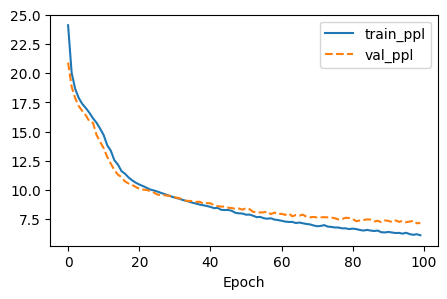

In [35]:
plt.figure(figsize=(5, 3))

plt.plot(range(num_epochs), list_train_ppl, label='train_ppl')
plt.plot(range(num_epochs), list_val_ppl, linestyle='--', label='val_ppl')

plt.xlabel('Epoch')

plt.legend()
plt.show()

## **Predict**

In [36]:
model.predict('i was', 50, data.vocab)

'i was an the par and the pare here the the time the par'